
# **Школа глубокого обучения ФПМИ МФТИ**

**Домашнее задание**

**Сегментация изображений**

В этом задании вам предстоит решить задачу сегментации медицинских снимков. Часть кода с загрузкой данных написана за вас. Всю содержательную сторону вопроса вам нужно заполнить самостоятельно. Задание оценивается из 15 баллов.

Обратите внимание, что отчёт по заданию стоит целых 6 баллов. Он вынесен в отдельный пункт в конце тетради. Это сделано для того, чтобы тетрадь была оформлена как законченный документ о проведении экспериментов. Неотъемлемой составляющей отчёта является ответ на следующие вопросы:

Что было сделано? Что получилось реализовать, что не получилось?
Какие результаты ожидалось получить?
Какие результаты были достигнуты?
Чем результаты различных подходов отличались друг от друга и от бейзлайна (если таковой присутствует)?

In [18]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        pass

# **1. Подготовка данных**

In [2]:
images = []
lesions = []
from skimage.io import imread
import os
root_input = '/kaggle/input/ph2dataset/trainx'
root_gts = '/kaggle/input/ph2dataset/trainy'

for file in os.listdir(root_input):
    images.append(imread(os.path.join(root_input, file)))
    lesions.append(imread(os.path.join(root_gts, file.split('.')[0]+'_lesion.bmp')))


In [1]:
images = []
lesions = []
import os

from skimage.io import imread

# root = 'E:\\data\\PH2Dataset'
# root = 'C:\\prj\\DLS\\data\\PH2Dataset'
root = 'D:\\Data\\PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

In [2]:
# Изображения имеют разные размеры. Давайте изменим их размер на  256×256  пикселей.
# Для изменения размера изображений можно использовать skimage.transform.resize().
# Эта функция также автоматически нормализует изображения в диапазоне  [0,1] .

from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [3]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


In [4]:
len(images), len(lesions)

(200, 200)

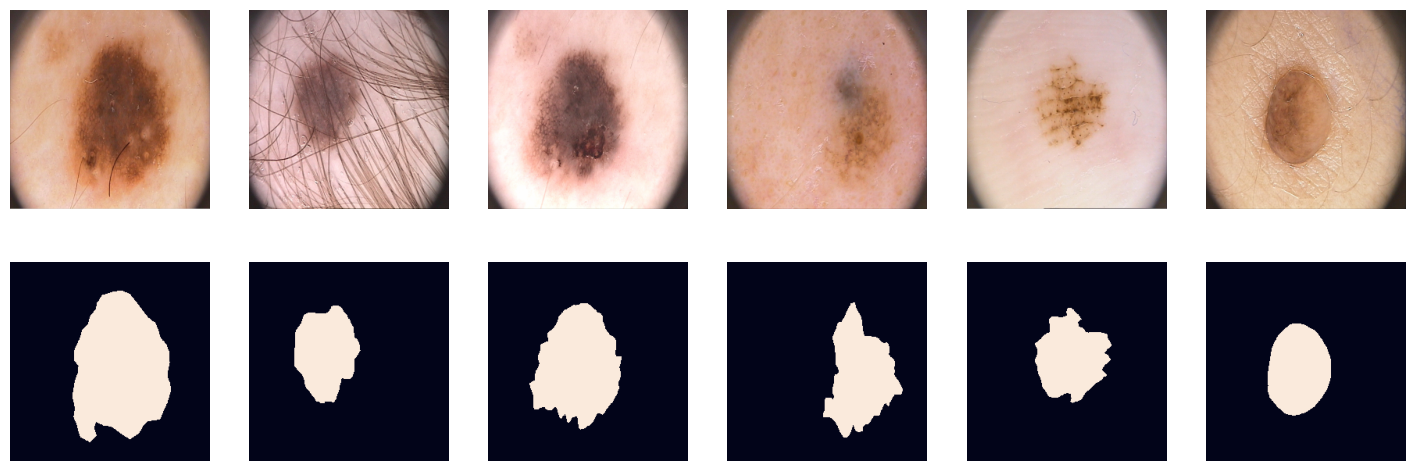

In [5]:
# Чтобы убедиться, что все корректно, мы нарисуем несколько изображений
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

In [6]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])
print(len(tr), len(val), len(ts))

100 50 50


In [7]:
# Затем мы используем PyTorch Dataloader для переноса наших наборов данных:
from torch.utils.data import DataLoader
batch_size = 4
data_tr = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])), 
                     batch_size=batch_size, shuffle=True)
data_val = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=True)
data_ts = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=True)

In [23]:
# Настройка графического устройства для обучения:
import torch
# device = torch.device('cuda')
device = torch.device('cpu')
print(device)
torch.cuda.is_available()

cpu


False

# **2. Архитектуры сегментационных сетей**

Будем использовать две сверточные сети для сегментации: Segment и U-Net

In [8]:
# Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки.
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

In [9]:
# Мы будем использовать сверточную сеть VGG16 в качестве примера для создания кодера нашей реализации SegNet
template = models.vgg16_bn()
#template

In [10]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling) consists of convolutional layers and pooling layers with ReLU activation and batchnorm

        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool0 =   nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                      dilation=1,
                                       ceil_mode=False, return_indices=True)
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool1 =  nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                     dilation=1,
                                      ceil_mode=False, return_indices=True)
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool2 =  nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                     dilation=1,
                                     ceil_mode=False, return_indices=True)
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool3 =  nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, return_indices=True)

        # bottleneck layer improves the training metrics
        self.bottleneck_enc = nn.Sequential(
            nn.Conv2d(512, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        # decoder (upsampling) consist of unpooling layers that are feeded with indexes from encoder and of conv layers
        # (with ReLU and batchnorm as well)
        self.upsample0 =  nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0)  # 16->32
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.upsample1 =  nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0) # 32 -> 64
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.upsample2 =   nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0) # 64 -> 128
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.upsample3 =   nn.MaxUnpool2d(kernel_size=2, stride=2, padding=0) # 128 -> 256
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
        )

    def forward(self, x):
        # encoder
        e0, idx0 = self.pool0(self.enc_conv0(x))
        e1, idx1 = self.pool1(self.enc_conv1(e0))
        e2, idx2 = self.pool2(self.enc_conv2(e1))
        e3, idx3 =self.pool3(self.enc_conv3(e2))

        # bottleneck
        b = self.bottleneck_enc(e3)
        # decoder: here we feed the indexes from encoder to the unpooling layers
        d0 =  self.dec_conv0(self.upsample0(b, idx3))
        d1 = self.dec_conv1(self.upsample1(d0, idx2))
        d2 = self.dec_conv2(self.upsample2(d1, idx1))
        d3 = self.dec_conv3(self.upsample3(d2, idx0))  # no activation
        return d3

# **3. Метрика, функция обучения и процесс обучения**

## 3.1 Метрика

В данном разделе предлагается использовать следующую метрику для оценки качества:

IoU=target ∩ prediction target ∪prediction 

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.

In [11]:
def iou_pytorch(outputs, labels):
    outputs = outputs.squeeze().byte()  # BATCH x 1 x H x W => BATCH x H x W
    labels =(labels).squeeze().byte()
    SMOOTH = 1e-8
    intersection = (outputs & labels).float().sum((1, 2))  # Will be zero if Truth=0 or Prediction=0
    union = (outputs | labels).float().sum((1, 2))         # Will be zero if both are 0
    
    iou = (intersection + SMOOTH) / (union + SMOOTH)  # We smooth our devision to avoid 0/0
    return iou

## 3.2 Функция потерь [1 балл]

Не менее важным, чем построение архитектуры, является определение оптимизатора и функции потерь.

Функция потерь - это то, что мы пытаемся минимизировать. Многие из них могут быть использованы для задачи бинарной семантической сегментации.

Популярным методом для бинарной сегментации является бинарная кросс-энтропия, которая задается следующим образом...

In [12]:
def BCEWithLogits(y_pred, y_true):
    bcelogits_loss = -y_true * torch.log(torch.sigmoid(y_pred)) - (1 - y_true) * torch.log(torch.sigmoid(1 - y_pred)) 
    # работает хорошо без упрощения
    
    return bcelogits_loss

In [13]:
def BCE_stabilized(y_pred, y_true):
    loss = torch.max(y_pred, torch.zeros_like(y_pred)) - y_pred*y_true + torch.log(1+torch.exp(-torch.abs(y_pred)))
    return loss

**3.3 Функция обучения [1 балл]**

In [14]:
def train(model, opt, loss_fn, epochs, data_tr, data_val, sched = None, freq = 1):
    history = []
    for epoch in range(epochs):
        tic = time()
        print(f'Epoch {epoch+1} of {epochs}')
        avg_val_loss = 0
        avg_loss = 0
        model.train()  # train mode
        for X_batch, Y_batch in data_tr:
            # data to device
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            # set gradients to zero
            opt.zero_grad()
            # forward
            Y_pred = model(X_batch)
            loss =  loss_fn(Y_pred, Y_batch)
            loss.mean().backward()
            opt.step()

            # calculate train loss
            avg_loss += loss.mean() / len(data_tr)
        toc = time()
        print(f'loss: {avg_loss}')

        # calculate val loss and metrics
        model.eval()  # testing mode
        with torch.no_grad():
            for X_val, Y_val in data_val:
                # data to device
                X_val, Y_val = X_val.to(device), Y_val.to(device)
                Y_val_pred = model(X_val)
                loss_val =  loss_fn(Y_val_pred, Y_val)
                avg_val_loss += loss_val.mean() / len(data_val)
            Y_hat = (torch.sigmoid(model(X_val).squeeze()) > 0.5).to(int)
            val_metric = iou_pytorch(Y_hat, Y_val)
            Y_train_hat = (torch.sigmoid(model(X_batch).squeeze()) > 0.5).to(int)
            train_metric = iou_pytorch(Y_train_hat, Y_batch)
        # make a scheduler step
        if sched:
            if epoch % freq == 0:
                sched.step()

        # save the training history
        history.append((avg_loss.item(), avg_val_loss.item(), train_metric.mean().item(), val_metric.mean().item()))

        # Visualize tools
        clear_output(wait=True)
        Y_hat = Y_hat.detach().cpu().numpy()
        plt.figure(figsize = (4,4))
        for k in range(2):
            plt.subplot(2, 2, k+1)
            plt.imshow(np.rollaxis(X_val[k].cpu().numpy(), 0, 3), cmap='gray')
            plt.title('Real')
            plt.axis('off')

            plt.subplot(2, 2, k+3)
            plt.imshow(Y_hat[k, :, :], cmap='gray')
            plt.title('Output')
            plt.axis('off')
        plt.suptitle('%d / %d - loss: %f' % (epoch+1, epochs, avg_loss))
        plt.show()
    return history

##3.4 Инференс [1 балл]

После обучения модели эту функцию можно использовать для прогнозирования сегментации на новых данных:

In [15]:
def predict(model, data):
    test_dataset = np.rollaxis(data, 3, 1)
    model.eval()  # testing mode
    Y_pred = np.zeros(len(data), dtype = 'object')
    idx = 0
    with torch.no_grad():
        X = torch.FloatTensor(test_dataset).to(device)
        preds = (torch.sigmoid(model(X)).squeeze() > 0.5).to(int).cpu().numpy()
        for X in preds:
                Y_pred[idx] = X
                idx+=1
    return Y_pred


In [16]:
def score_model(model, metric, data):
    model.eval()  # testing mode
    scores = 0
    with torch.no_grad():
        for X_batch, Y_label in data:
            Y_pred = (torch.sigmoid(model(X_batch.to(device)).squeeze()) > 0.5).to(int)
            scores += metric(Y_pred, Y_label.to(device)).mean().item()
    return scores/len(data)

## 3.4 Основной момент: обучение

Обучите вашу модель. Обратите внимание, что обучать необходимо до сходимости. Если указанного количества эпох (20) не хватило, попробуйте изменять количество эпох до сходимости алгоритма. Сходимость определяйте по изменению функции потерь на валидационной выборке.

С параметрами оптимизатора можно спокойно играть, пока вы не найдете лучший вариант для себя.

In [20]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.memory_allocated()

0

In [24]:
model = SegNet().to(device)
max_epochs = 50
opt = torch.optim.AdamW(model.parameters(), lr = 4e-5, weight_decay = 1e-4)
history_bce = train(model, opt, BCEWithLogits, max_epochs, data_tr, data_val)


Epoch 4 of 50


KeyboardInterrupt: 

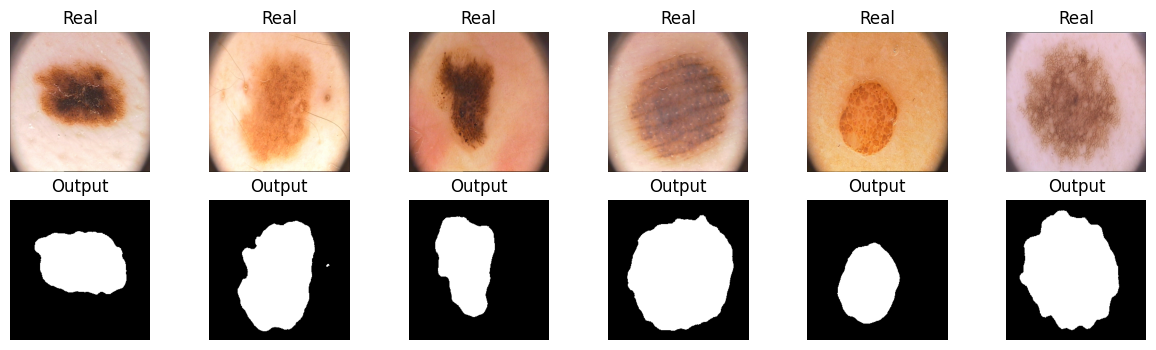

In [21]:
# Проверим, как работает функция прогнозирования:
Y_pred = predict(model, X[ts])

for k in range(6):
    plt.subplot(2, 6, k+1)
    plt.imshow(X[ts][k])
    plt.title('Real')
    plt.axis('off')
    
    plt.subplot(2, 6, k+7)
    plt.imshow(Y_pred[k], cmap='gray')
    plt.title('Output')
    plt.axis('off')

# it works okay and the model is strong enough to train on our small dataset!

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

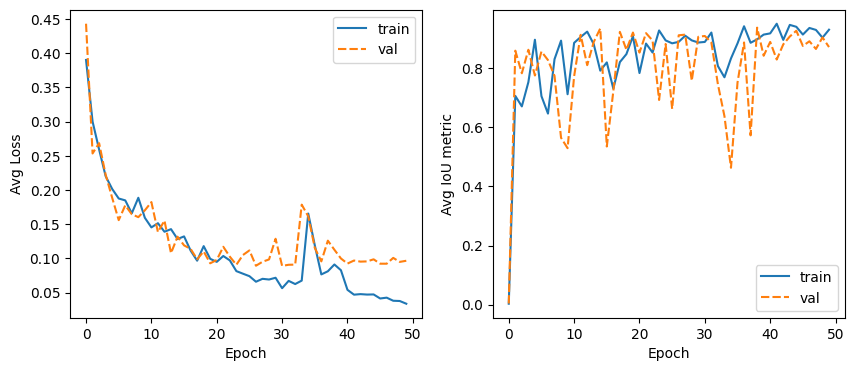

In [22]:
# Визуализация процесса обучения:¶
def visualize_and_save(history, savename):
    loss_tr, loss_val, metric_tr, metric_val = zip(*history)
    from seaborn import lineplot
    graphs = plt.figure(figsize = (10, 4))
    ax1 = plt.subplot(1,2,1)
    lineplot({'train': loss_tr, 'val' : loss_val})
    plt.xlabel('Epoch')
    plt.ylabel('Avg Loss')
    ax2 = plt.subplot(1,2,2)
    lineplot({'train':metric_tr, 'val':metric_val})
    plt.xlabel('Epoch')
    plt.ylabel('Avg IoU metric');

    # we save the training history for future use
    import pickle
    with open(savename, 'wb') as file:
        pickle.dump(history, file)

visualize_and_save(history_bce, 'history_bce')

In [23]:
# Результирующая оценка:
round(score_model(model, iou_pytorch, data_val),3)

0.874

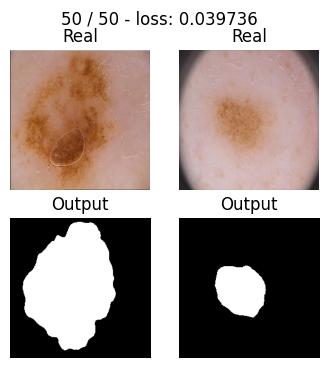

In [24]:
# Stable BCE loss
model_stable = SegNet().to(device)
max_epochs = 50
opt = torch.optim.AdamW(model_stable.parameters(), lr = 4e-5, weight_decay = 1e-4)
history_bce_stable = train(model_stable, opt, BCE_stabilized, max_epochs, data_tr, data_val)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

0.881

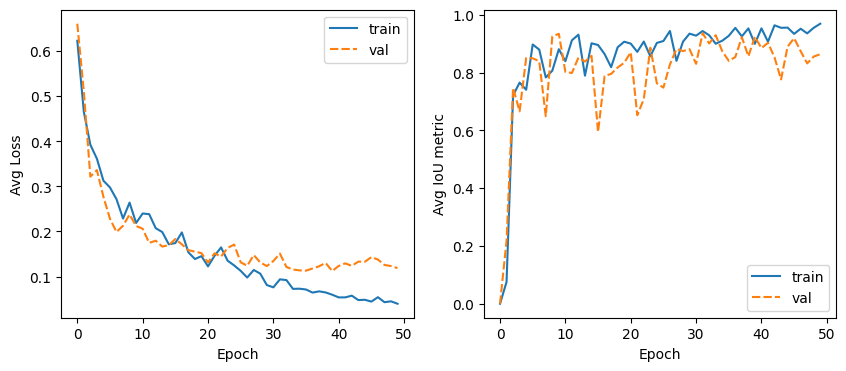

In [26]:
visualize_and_save(history_bce_stable, 'history_bce_stable')

round(score_model(model_stable, iou_pytorch, data_val),3)

## 3.5 Дополнительные функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss. Если у вас что-то не учится, велика вероятность, что вы ошиблись или учите слишком мало эпох, прежде чем бить тревогу попробуйте перебрать различные варианты и убедитесь, что во всех других сетапах сеть достигает желанного результата. СПОЙЛЕР: учиться она будет при всех лоссах, предложенных в этом задании...

In [ ]:
def dice_loss(y_pred, y_real):
    y_real = y_real.squeeze()
    y_pred = torch.sigmoid(y_pred.squeeze())
    Smooth = 1e-8
    num = (y_real*y_pred).sum((1,2))
    den = y_real.sum((1,2)) + (y_pred.sum((1,2))) + Smooth
    res = 1 - 2 * num  / den
    return res

Проводим тестирование:

In [ ]:
model_dice = SegNet().to(device)

max_epochs = 50
optimizer = torch.optim.AdamW(model_dice.parameters(), lr = 4e-5, weight_decay = 1e-4)
history_dice = train(model_dice, optimizer, dice_loss, max_epochs, data_tr, data_val)

import pickle
with open('history_dice', 'wb') as file2:
    pickle.dump(history_dice, file2)

In [ ]:
visualize_and_save(history_dice, 'history_dice')

In [ ]:
score_model(model_dice, iou_pytorch, data_val)

**Focal loss:**

Окей, мы уже с вами умеем делать BCE loss...

In [ ]:
def focal_loss(y_pred, y_true, gamma = 2):
    alpha = (1-torch.sigmoid(-torch.abs(y_pred)))**gamma
    loss = torch.max(y_pred, torch.zeros_like(y_pred)) - y_pred*y_true + torch.log(1+torch.exp(-torch.abs(y_pred)))
    focal_loss = alpha * loss
    return loss

In [ ]:
# Эффективность focal_loss
model_focal = SegNet().to(device)
max_epochs = 50
optimizer = torch.optim.AdamW(model_focal.parameters(), lr = 4e-5, weight_decay = 1e-4)
history_focal = train(model_focal, optimizer, focal_loss, max_epochs, data_tr, data_val)

In [ ]:
visualize_and_save(history_focal, 'history_focal')

In [ ]:
score_model(model_focal, iou_pytorch, data_val)

**3.6. [BONUS] Мир сегментационных лоссов [5 баллов]**

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее. Кроме тако провести численное сравнение с предыдущими функциями ...

**Lovasz loss**

In [ ]:
from torch.autograd import Variable

def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

class LovaszSoftmax(nn.Module):
    def __init__(self, reduction='mean'):
        super(LovaszSoftmax, self).__init__()
        self.reduction = reduction

    def prob_flatten(self, input_, target):
        input_flatten = input_.squeeze().view(-1)
        target_flatten = target.squeeze().view(-1)
        return input_flatten, target_flatten

    def lovasz_softmax_flat(self, inputs, targets):
        loss = (torch.autograd.Variable(targets) - inputs).abs()
        loss_sorted, loss_index = torch.sort(loss, descending=True)
        target_sorted = targets[loss_index]
        losses= torch.dot(loss_sorted, torch.autograd.Variable(lovasz_grad(target_sorted)))

        if self.reduction == 'none':
            losses = losses
        elif self.reduction == 'sum':
            losses = losses.sum()
        return losses

    def forward(self, inputs, targets):
        inputs, targets = self.prob_flatten(inputs, targets)
        losses = self.lovasz_softmax_flat(inputs, targets)
        return losses

In [ ]:
model_lova = SegNet().to(device)
max_epochs = 50
optimizer = torch.optim.AdamW(model_lova.parameters(), lr = 4e-5, weight_decay = 1e-4)
history_lova = train(model_lova, optimizer, LovaszSoftmax(), max_epochs, data_tr, data_val)

In [ ]:
visualize_and_save(history_lova, 'history_lova')

In [ ]:
score_model(model_lova, iou_pytorch, data_val)

# **4. U-Net [2 балла]**

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder
        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool0 =   nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                      dilation=1,
                                       ceil_mode=False)
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool1 =  nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                     dilation=1,
                                      ceil_mode=False)
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool2 =  nn.MaxPool2d(kernel_size=2, stride=2, padding=0,
                                     dilation=1,
                                     ceil_mode=False)
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool3 =  nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

        self.enc_conv4 = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(1024),
            nn.ReLU()
        )
        # decoder (upsampling)
        self.upsample0 =  nn.Sequential(
            nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2),  # 16->32
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )
        self.upsample1 =  nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU()
        ) # 32 -> 64
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.upsample2 =   nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU()
        ) # 64 -> 128
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.upsample3 =   nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 16->32
            nn.BatchNorm2d(64),
            nn.ReLU()
        ) # 128 -> 256
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1), padding='same', padding_mode='reflect'),
        )

    def forward(self, x):
        # encoder
        e0 = self.enc_conv0(x)
        e0_pool = self.pool0(e0)
        e1 = self.enc_conv1(e0_pool)
        e1_pool = self.pool1(e1)
        e2 = self.enc_conv2(e1_pool)
        e2_pool = self.pool2(e2)
        e3 = self.enc_conv3(e2_pool)
        e3_pool = self.pool3(e3)
        e4 = self.enc_conv4(e3_pool)
        # decoder
        e3_up = self.upsample0(e4)
        d0 = self.dec_conv0(torch.cat((e3_up,e3), dim = 1))
        d0_up = self.upsample1(d0)
        d1 = self.dec_conv1(torch.cat((d0_up,e2), dim = 1))
        d1_up = self.upsample2(d1)
        d2 = self.dec_conv2(torch.cat((d1_up,e1), dim = 1))
        d2_up = self.upsample3(d2)
        d3 = self.dec_conv3(torch.cat((d2_up,e0), dim = 1))
        return d3

In [ ]:
unet_model = UNet().to(device)
history_unet = train(unet_model, optim.AdamW(unet_model.parameters(), lr = 4e-5, weight_decay = 1e-4), BCE_stabilized, 50, data_tr, data_val)

In [ ]:
visualize_and_save(history_unet, 'history_unet')

In [ ]:
score_model(unet_model, iou_pytorch, data_val)

**Вариация U-Net (U-Net2)**

In [ ]:
# Изменения в кодере: замена максимального объединения на свертки с шагом =2
# Изменения в декодере: транспонированные свертки заменены на повышающую дискретизацию
class UNet2(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)

        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool0 =   nn.Conv2d(64, 64, 3, stride = 2, padding = 1)
        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool1 =  nn.Conv2d(128, 128, 3, stride = 2, padding = 1)
        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool2 =  nn.Conv2d(256, 256, 3, stride = 2, padding = 1)
        self.enc_conv3 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.pool3 =  nn.Conv2d(512, 512, 3, stride = 2, padding = 1)

        self.enc_conv4 = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(1024),
            nn.ReLU()
        )
        # decoder (upsampling)
        self.upsample0 =  nn.Sequential(nn.Upsample(scale_factor = 2),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding='same', padding_mode='reflect'),  # 16->32
            nn.BatchNorm2d(512),
            nn.ReLU()
            )
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )
        self.upsample1 =  nn.Sequential(nn.Upsample(scale_factor = 2),
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU()
            )
          # 32 -> 64
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.upsample2 =   nn.Sequential(nn.Upsample(scale_factor = 2),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU()
            )
            # 64 -> 128
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.upsample3 =   nn.Sequential(nn.Upsample(scale_factor = 2),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(64),
            nn.ReLU()
            )
         # 128 -> 256
        self.dec_conv3 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding='same', padding_mode='reflect'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1), padding='same', padding_mode='reflect'),
        )

    def forward(self, x):
        # encoder
        e0 = self.enc_conv0(x)
        e0_pool = self.pool0(e0)
        e1 = self.enc_conv1(e0_pool)
        e1_pool = self.pool1(e1)
        e2 = self.enc_conv2(e1_pool)
        e2_pool = self.pool2(e2)
        e3 = self.enc_conv3(e2_pool)
        e3_pool = self.pool3(e3)
        e4 = self.enc_conv4(e3_pool)
        # decoder
        e3_up = self.upsample0(e4)
        d0 = self.dec_conv0(torch.cat((e3_up,e3), dim = 1))
        d0_up = self.upsample1(d0)
        d1 = self.dec_conv1(torch.cat((d0_up,e2), dim = 1))
        d1_up = self.upsample2(d1)
        d2 = self.dec_conv2(torch.cat((d1_up,e1), dim = 1))
        d2_up = self.upsample3(d2)
        d3 = self.dec_conv3(torch.cat((d2_up,e0), dim = 1))
        return d3

In [ ]:
unet2_model = UNet2().to(device)
history_unet2 = train(unet2_model, optim.AdamW(unet2_model.parameters(), lr = 4e-5, weight_decay = 1e-4),BCE_stabilized, 50, data_tr, data_val)

In [ ]:
visualize_and_save(history_unet2, 'history_unet2')

In [ ]:
score_model(unet2_model, iou_pytorch, data_val)

**Dice**

In [ ]:
# Производительность U-Net и Net2 практически идентична.¶
# Давайте выберем U-Net v2 и попробуем использовать разные потери в этой модели
unet_dice = UNet2().to(device)
history_udice = train(
    unet_dice,
    optim.AdamW(unet_dice.parameters(),
    lr = 4e-5, weight_decay = 1e-4), dice_loss, 50, data_tr, data_val)

In [ ]:
visualize_and_save(history_udice, 'history_udice')

In [ ]:
score_model(unet_dice, iou_pytorch, data_val)

**Focal**

In [ ]:
unet_focal = UNet2().to(device)
history_ufocal = train(unet_focal, optim.AdamW(unet_focal.parameters(), lr = 4e-5, weight_decay = 1e-4), focal_loss, 50, data_tr, data_val)

In [ ]:
visualize_and_save(history_ufocal, 'history_ufocal')

In [ ]:
score_model(unet_focal, iou_pytorch, data_val)

**Lovasz**

In [ ]:
unet_lova = UNet2().to(device)
history_ulova = train(unet_lova, optim.AdamW(unet_lova.parameters(), lr = 4e-5, weight_decay = 1e-4), LovaszSoftmax(), 50, data_tr, data_val)

In [ ]:
visualize_and_save(history_ulova, 'history_ulova')

In [ ]:
score_model(unet_lova, iou_pytorch, data_val)

# **5. Отчет (6 баллов):**

Ниже предлагается написать отчет о проделанно работе и построить графики для лоссов, метрик на валидации и тесте. Если вы пропустили какую-то часть в задании выше, то вы все равно можете получить основную часть баллов в отчете, если правильно зададите проверяемые вами гипотезы.

Аккуратно сравните модели между собой и соберите наилучшую архитектуру. Проверьте каждую модель с различными лоссами. Мы не ограничиваем вас в формате отчета, но проверяющий должен отчетливо понять для чего построен каждый график, какие выводы вы из него сделали и какой общий вывод можно сделать на основании данных моделей. Если вы захотите добавить что-то еще, чтобы увеличить шансы получения максимального балла, то добавляйте отдельное сравнение.

Дополнительные комментарии:

Пусть у вас есть N обученных моделей.

Является ли отчетом N графиков с 1 линей? Да, но очень низкокачественным, потому что проверяющий не сможет сам сравнить их.

Является ли отчетом 1 график с N линиями? Да, но скорее всего таким образом вы отразили лишь один эффект. Этого мало, чтобы сделать досточно суждений по поводу вашей работа.

Я проверял метрики на трейне, и привел в результате таблицу с N числами, что не так? ключейвой момент тут, что вы измеряли на трейне ваши метрики, уверены ли вы, что заивисмости останутся такими же на отложенной выборке?

Я сделал отчет содержащий график лоссов и метрик, и у меня нет ошибок в основной части, но за отчет не стоит максимум, почему? Естестественно максимум баллов за отчет можно получить не за 2 графика (даже при условии их полной правильности). Проверяющий хочет видеть больше сравнений моделей, чем метрики и лоссы (особенно, если они на трейне).


**6.1 Общие соображения о производительности SegNet и U-Net:**

- обе модели достаточно надежны для обучения на этом относительно небольшом наборе данных;

- модели не подвержены переобучению, хотя регуляризация l2 повышает стабильность обучения;

- oбе модели ведут себя одинаково в процессе обучения: оценка IoU подскакивает до ~0,7 за 3-5 периодов, а затем медленно повышается;

- batch_size = 4 предотвращает переобучение и обеспечивает оптимальную производительность.

**6.2 Анализ скорости схождения:**

Можно сравнить количество периодов, необходимых для схождения каждой модели, после чего можно останавливать обучение

In [ ]:
# Функция определения, в какую эпоху модель сходится.
# Функция возвращает среднюю эпоху интервала, если потери изменяются менее чем на 3% на интервале в 8 эпох

def plateau(history_filename):
    import pickle, os
    with open(history_filename, 'rb') as f:
        history = pickle.load(f)
    loss_tr, loss_val, metric_tr, metric_val = zip(*history)
    pars = {'IoU_val': metric_val,
            'IoU_train':metric_tr}
    convergence = {'IoU_train':[], 'IoU_val':[]}
    for name, parameter in pars.items():
        for idx in range(len(parameter)-7):
            deriv = (parameter[idx+7]-parameter[idx])/8
            relative_deriv = deriv/parameter[idx] * 100
            if abs(relative_deriv) < 0.03:
                convergence[name].append(idx+4)
        if not convergence[name]:
            convergence[name] = 50
        else:
            convergence[name] = max(convergence[name])
    return convergence

In [ ]:
import pandas as pd
import os
convergence_df = pd.DataFrame(columns = ['Model', 'IoU train', 'IoU val'])
files = [x for x in os.listdir() if x.startswith('history')]
for m in range(len(files)):
    conv = plateau(files[m])
    convergence_df.loc[m,:] = [files[m].split('_')[-1], conv['IoU_train'], conv['IoU_val']]

In [ ]:
# Столбец для фрейма данных, представляющего базовую модель
convergence_df['Architecture'] = ['']*len(convergence_df)
segnet_l = pd.Series(['bce','stable','focal','dice',])
unet_l = pd.Series(['unet','unet2','ufocal','udice'])
convergence_df.set_index('Model', inplace = True)
for i in segnet_l:
    convergence_df.loc[i,'Architecture'] = 'SegNet'
for i in unet_l:
    convergence_df.loc[i,'Architecture'] = 'U-Net'
order_l = pd.concat([segnet_l, unet_l])

In [ ]:
# Период, когда модель перестает улучшаться:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12, 6))
plt.subplot(1,2,1)
sns.barplot(data = convergence_df, x = convergence_df.index, y='IoU train',
            order = order_l, hue = 'Architecture')
plt.title('Train dataset')
plt.subplot(1,2,2)
sns.barplot(data = convergence_df, x = convergence_df.index, y='IoU val',
        order = order_l, hue = 'Architecture')
plt.title('Val dataset')

**Результат:**

- SegNet быстрее сходится к набору данных train, чем U-Net

- U-Net2 быстрее сходится к набору данных val, чем U-Net

- Сегнет с потерей данных dice показывает самую быструю сходимость как к данным train, так и к данным val во всех моделях

**6.3 Оценим производительность каждой модели в тестовом наборе данных и сравним показатели**

Примечание: Lovasz softmax исключены из оценки, поскольку они показали низкую производительность.

In [ ]:
models = {
    'SegNet': model, 'SegNet stable':model_stable, 'SegNet Dice':model_dice, 'SegNet focal':model_focal,
     'U-Net':unet_model, 'U-Net2':unet2_model,
    'U-Net2 Dice':unet_dice, 'U-Net2 focal':unet_focal
}
metric_test = {}
for key, cur_model in models.items():
    metric_test[key] = round(score_model(cur_model, iou_pytorch, data_ts), 3)

In [ ]:
metric_df = pd.DataFrame({'Models':metric_test.keys(), 'Values':metric_test.values()})

In [ ]:
plt.figure(figsize = (10,5))
sns.barplot(x = metric_df['Models'], y = metric_df['Values'])
plt.xlabel('Model')
plt.ylabel('IoU on test')
plt.title(label = 'Performance dependent on model and loss', pad = None)
plt.ylim(bottom = 0.7);

**Выводы из сравнения показателей** 

- последующие запуски одной и той же модели дают разные показатели в диапазоне от .84 до.88, вероятно, из-за небольшого размера набора данных. Таким образом, сложно делать какие-либо предположения;

- потери в dice дают небольшое преимущество при тестировании для SegNet по сравнению с bce, в то время как focal+Segnet имеет наихудшие показатели среди других вариантов;

- UNet2+BCE loss немного лучше, чем U-Net.

**Выбор наилучшей модели и потери для набора данных PH2**

Ограничение: из-за различий в производительности модели каждая комбинация должна быть запущена несколько раз, при этом лучше использовать среднюю эпоху сходимости

- UNet2 с BCE loss работает лучше всех комбинаций U-Net+loss, как с точки зрения скорости сходимости, так и эффективности;

- для SegNet сходимость намного быстрее в dice, при этом обеспечивается несколько лучшее качество при тестировании.